<a href="https://colab.research.google.com/github/Pooya-Moayed/Bachelors-Desertation/blob/Classification/Pooya_Project_Classification_Zone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Project/Data - Class2.xlsx',index_col=None)

data.head()

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,Class 2
0,191,241,238,236,249,8.2,8514,1321,45,3
1,194,240,235,234,251,8.2,7184,1158,45,3
2,194,241,233,234,249,8.2,8546,1350,50,3
3,194,242,242,234,250,8.7,8337,1427,50,3
4,195,239,239,237,250,8.3,8262,1409,45,3


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('Class 2', axis=1)
y = data['Class 2']

In [ ]:
X

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
0,191,241,238,236,249,8.2,8514,1321,45
1,194,240,235,234,251,8.2,7184,1158,45
2,194,241,233,234,249,8.2,8546,1350,50
3,194,242,242,234,250,8.7,8337,1427,50
4,195,239,239,237,250,8.3,8262,1409,45
...,...,...,...,...,...,...,...,...,...
264,195,233,236,237,251,7.9,8276,1388,50
265,183,233,230,232,252,7.9,7986,1331,45
266,183,233,237,233,251,7.9,7969,1384,45
267,188,231,241,237,250,9.3,8065,1288,40


In [ ]:
y

0      3
1      3
2      3
3      3
4      3
      ..
264    4
265    4
266    4
267    4
268    4
Name: Class 2, Length: 269, dtype: int64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
115,194,239,239,238,252,7.50,8300,1435,40
33,192,242,238,241,250,8.10,8544,1471,40
180,191,239,241,238,250,7.70,8085,1270,45
141,190,236,235,235,251,7.40,8495,1445,40
248,187,235,238,238,249,7.90,8257,1350,45
...,...,...,...,...,...,...,...,...,...
20,196,241,238,235,249,8.40,8591,1299,50
188,191,239,234,237,249,7.75,8067,1325,35
71,194,238,236,236,249,7.90,8232,1312,35
106,186,237,238,239,250,7.50,8290,1335,40


In [ ]:
X_test

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
30,194,238,240,237,250,8.10,8374,1459,50
116,194,238,236,234,251,7.50,8460,1470,35
79,186,242,239,234,250,8.50,8481,1310,40
127,189,239,238,233,249,7.50,8377,1419,45
190,191,240,237,235,248,7.50,8322,1403,45
137,191,240,242,241,251,7.50,8258,1318,50
202,191,241,233,235,251,7.75,8271,1430,45
45,191,241,238,235,249,8.20,8314,1470,45
173,192,232,237,236,251,7.70,8251,1290,50
239,191,239,235,235,251,8.50,8135,1440,45


In [ ]:
y_train

115    3
33     2
180    3
141    4
248    4
      ..
20     1
188    3
71     4
106    4
102    3
Name: Class 2, Length: 215, dtype: int64

In [ ]:
y_test

30     4
116    4
79     3
127    3
190    3
137    3
202    2
45     3
173    4
239    3
179    4
267    4
220    4
82     4
186    3
185    4
241    4
265    4
104    2
60     2
261    4
184    2
46     3
42     3
181    4
9      2
22     4
193    3
109    2
24     3
113    3
68     4
143    3
217    4
197    3
6      4
120    3
67     3
119    4
118    2
25     3
125    3
165    3
19     4
77     2
209    4
90     3
170    4
93     3
258    3
15     3
150    4
224    4
242    4
Name: Class 2, dtype: int64

In [ ]:
y_test.value_counts()

4    23
3    23
2     8
Name: Class 2, dtype: int64

In [ ]:
y_train.value_counts()

4    101
3     73
2     36
1      5
Name: Class 2, dtype: int64

##Imbalanced Data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE

smote = SMOTE(sampling_strategy='minority')
#smote = BorderlineSMOTE(sampling_strategy='not majority')


#Creating new samples by SMOTE sampling
X_sm, y_sm = smote.fit_resample(X,y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.1, stratify=y_sm)

ValueError: ignored

In [ ]:
from imblearn.over_sampling import ADASYN

sm = ADASYN(sampling_strategy='not majority')
X_sm2, y_sm2 = sm.fit_resample(X, y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm2, y_sm2, test_size=0.1, stratify=y_sm2)

##Pearson Correlation  (detecting highly correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

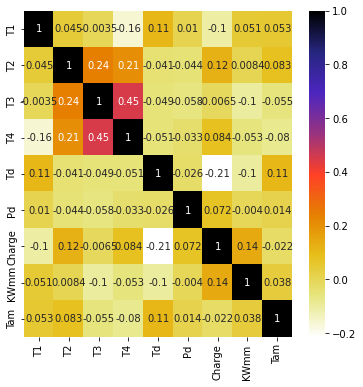

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.2 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Test the models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from logitboost import LogitBoost


from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score, fbeta_score, hamming_loss, matthews_corrcoef, log_loss, f1_score, average_precision_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, cohen_kappa_score
from imblearn.metrics import sensitivity_score, specificity_score, geometric_mean_score
import numpy as np



# 3.1. Ridge Classification Model

In [ ]:
from sklearn.linear_model import RidgeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = RidgeClassifier()
model.fit(X_train, y_train)

RidgeClassifier()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.7777777777777778

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.74074074, 0.61111111, 0.72222222, 0.7962963 , 0.69811321])

In [ ]:
y_preds = model.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.         1.         0.        ]
 [0.         0.86956522 0.13043478]
 [0.         0.04347826 0.95652174]]
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         8
           3       0.69      0.87      0.77        23
           4       0.88      0.96      0.92        23

    accuracy                           0.78        54
   macro avg       0.52      0.61      0.56        54
weighted avg       0.67      0.78      0.72        54



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([4, 4, 3, 4, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 3, 3, 4, 4, 3, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 3, 3, 3, 4, 3, 4, 3, 4, 3, 3, 4, 3, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 3, 3, 4, 4, 4])

In [ ]:
#y_test[:10]
y_test

30     4
116    4
79     3
127    3
190    3
137    3
202    2
45     3
173    4
239    3
179    4
267    4
220    4
82     4
186    3
185    4
241    4
265    4
104    2
60     2
261    4
184    2
46     3
42     3
181    4
9      2
22     4
193    3
109    2
24     3
113    3
68     4
143    3
217    4
197    3
6      4
120    3
67     3
119    4
118    2
25     3
125    3
165    3
19     4
77     2
209    4
90     3
170    4
93     3
258    3
15     3
150    4
224    4
242    4
Name: Class 2, dtype: int64

# 3.2. Random Forest Classification Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestClassifier(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.8888888888888888

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.7037037 , 0.77777778, 0.81481481, 0.87037037, 0.83018868])

In [ ]:
y_preds = rf.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.625      0.375      0.        ]
 [0.08695652 0.86956522 0.04347826]
 [0.         0.         1.        ]]
              precision    recall  f1-score   support

           2       0.71      0.62      0.67         8
           3       0.87      0.87      0.87        23
           4       0.96      1.00      0.98        23

    accuracy                           0.89        54
   macro avg       0.85      0.83      0.84        54
weighted avg       0.88      0.89      0.89        54



## 3.3. KNeighbours Classification Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsClassifier(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

0.4074074074074074

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([0.44444444, 0.44444444, 0.44444444, 0.37037037, 0.52830189])

In [ ]:
y_preds = neigh.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.         0.25       0.75      ]
 [0.         0.08695652 0.91304348]
 [0.         0.13043478 0.86956522]]
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         8
           3       0.29      0.09      0.13        23
           4       0.43      0.87      0.57        23

    accuracy                           0.41        54
   macro avg       0.24      0.32      0.23        54
weighted avg       0.30      0.41      0.30        54



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 3.4. DecisionTree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.7222222222222222

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.66666667, 0.74074074, 0.81481481, 0.83333333, 0.73584906])

In [ ]:
y_preds = dt.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.625      0.375      0.        ]
 [0.13043478 0.7826087  0.08695652]
 [0.13043478 0.17391304 0.69565217]]
              precision    recall  f1-score   support

           2       0.45      0.62      0.53         8
           3       0.72      0.78      0.75        23
           4       0.89      0.70      0.78        23

    accuracy                           0.72        54
   macro avg       0.69      0.70      0.69        54
weighted avg       0.75      0.72      0.73        54



# 3.5. SVM (Support Vector Machine)

In [ ]:
from sklearn import svm
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
svr = svm.SVC()
svr.fit(X_train,y_train)

SVC()

In [ ]:
#Evaluate our model
svr.score(X_test, y_test)

0.42592592592592593

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(svr, X, y, cv=5)

array([0.44444444, 0.46296296, 0.46296296, 0.46296296, 0.47169811])

In [ ]:
y_preds = svr.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00        23
           4       0.43      1.00      0.60        23

    accuracy                           0.43        54
   macro avg       0.14      0.33      0.20        54
weighted avg       0.18      0.43      0.25        54



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 3.6. XGBOOST

In [ ]:
from xgboost import XGBClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBClassifier( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

XGBClassifier(max_depth=50, objective='multi:softprob')

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.8703703703703703

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

array([0.66666667, 0.7962963 , 0.81481481, 0.85185185, 0.79245283])

In [ ]:
y_preds = xgb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.625      0.375      0.        ]
 [0.13043478 0.82608696 0.04347826]
 [0.         0.         1.        ]]
              precision    recall  f1-score   support

           2       0.62      0.62      0.62         8
           3       0.86      0.83      0.84        23
           4       0.96      1.00      0.98        23

    accuracy                           0.87        54
   macro avg       0.82      0.82      0.82        54
weighted avg       0.87      0.87      0.87        54



#3.7. CATBOOST

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb =  CatBoostClassifier(iterations=100, learning_rate = 1.0, objective='MultiClass')
catb.fit(X_train,y_train)

0:	learn: 0.6435491	total: 49.3ms	remaining: 4.88s
1:	learn: 0.5339717	total: 51.7ms	remaining: 2.53s
2:	learn: 0.4746958	total: 53.5ms	remaining: 1.73s
3:	learn: 0.4173749	total: 55.1ms	remaining: 1.32s
4:	learn: 0.3561991	total: 57ms	remaining: 1.08s
5:	learn: 0.3093153	total: 58.7ms	remaining: 919ms
6:	learn: 0.2724534	total: 60.3ms	remaining: 801ms
7:	learn: 0.2367823	total: 61.8ms	remaining: 711ms
8:	learn: 0.2047106	total: 63.4ms	remaining: 641ms
9:	learn: 0.1917434	total: 65.1ms	remaining: 586ms
10:	learn: 0.1783011	total: 67ms	remaining: 542ms
11:	learn: 0.1704940	total: 68.7ms	remaining: 504ms
12:	learn: 0.1594144	total: 70.3ms	remaining: 471ms
13:	learn: 0.1430453	total: 72.2ms	remaining: 443ms
14:	learn: 0.1276675	total: 74.2ms	remaining: 420ms
15:	learn: 0.1155680	total: 76.1ms	remaining: 400ms
16:	learn: 0.1101809	total: 78ms	remaining: 381ms
17:	learn: 0.1063017	total: 79.8ms	remaining: 364ms
18:	learn: 0.0993735	total: 81.5ms	remaining: 348ms
19:	learn: 0.0953739	total: 

In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.8888888888888888

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 0.5246398	total: 2.34ms	remaining: 231ms
1:	learn: 0.4169284	total: 4.46ms	remaining: 219ms
2:	learn: 0.3437335	total: 6.2ms	remaining: 201ms
3:	learn: 0.2972817	total: 8.14ms	remaining: 195ms
4:	learn: 0.2727730	total: 9.96ms	remaining: 189ms
5:	learn: 0.2511847	total: 11.8ms	remaining: 185ms
6:	learn: 0.2220849	total: 13.6ms	remaining: 181ms
7:	learn: 0.1952468	total: 15.4ms	remaining: 177ms
8:	learn: 0.1769608	total: 20.4ms	remaining: 206ms
9:	learn: 0.1616805	total: 23.7ms	remaining: 213ms
10:	learn: 0.1491535	total: 25.5ms	remaining: 207ms
11:	learn: 0.1332819	total: 27ms	remaining: 198ms
12:	learn: 0.1206544	total: 28.6ms	remaining: 192ms
13:	learn: 0.1080070	total: 30.5ms	remaining: 188ms
14:	learn: 0.1008603	total: 32.3ms	remaining: 183ms
15:	learn: 0.0942278	total: 34.2ms	remaining: 179ms
16:	learn: 0.0899827	total: 36.1ms	remaining: 176ms
17:	learn: 0.0860886	total: 37.9ms	remaining: 173ms
18:	learn: 0.0833023	total: 39.6ms	remaining: 169ms
19:	learn: 0.0788775	tota

array([0.68518519, 0.81481481, 0.83333333, 0.83333333, 0.73584906])

In [ ]:
y_preds = catb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.625      0.375      0.        ]
 [0.04347826 0.91304348 0.04347826]
 [0.         0.04347826 0.95652174]]
              precision    recall  f1-score   support

           2       0.83      0.62      0.71         8
           3       0.84      0.91      0.87        23
           4       0.96      0.96      0.96        23

    accuracy                           0.89        54
   macro avg       0.88      0.83      0.85        54
weighted avg       0.89      0.89      0.89        54



##Results

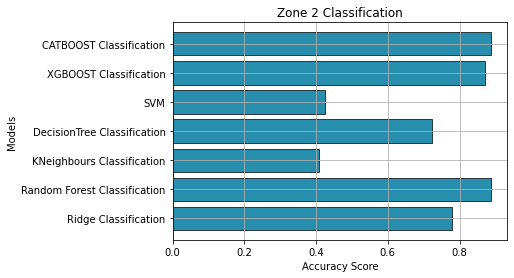

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_valeues=['Ridge Classification', 'Random Forest Classification', 'KNeighbours Classification',
           'DecisionTree Classification', 'SVM', 'XGBOOST Classification', 'CATBOOST Classification']

y_valeues=[model.score(X_test, y_test), rf.score(X_test, y_test), neigh.score(X_test, y_test), dt.score(X_test, y_test),
           svr.score(X_test, y_test), xgb.score(X_test, y_test), catb.score(X_test, y_test)]

width=1

# plot
plt.barh(x_valeues, y_valeues, color='#288ead', edgecolor="black", linewidth=0.7)

plt.xlabel('Accuracy Score')
plt.ylabel('Models')
plt.title('Zone 2 Classification')
plt.grid(True)


plt.show()